1. ***IMPORT LIBRARIES***

In [1]:
# import libraries(for data cleaning,preprocessing and data analysis)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import libraries(for m models)
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

2. ***LOAD DATASET***

In [2]:
# uplode  dataset and read the dataset
df = pd.read_csv("/content/used_cars.csv")
df.head()
df.shape #row and columns
df.columns #all feature names
df.info() #data tpyes,missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


***# 3. DATA CLEANING***


In [3]:
# clean price colume(remove $ and,)
df['price'] = df['price'].replace(r'[\$,]','',regex=True).astype(float)
# clean milage column
df['milage'] = df['milage'].astype(str)
df['milage']=df['milage'].str.replace(',','')
df['milage']=df['milage'].str.replace('mi.','')
df['milage']=df['milage'].astype(float)
# fill the missing values
mode_fuel_type = df['fuel_type'].mode()
if not mode_fuel_type.empty:
    df['fuel_type'] = df['fuel_type'].fillna(mode_fuel_type[0])
else:
    df['fuel_type'] = df['fuel_type'].fillna('Unknown') # Fallback if no mode found
df['accident'] = df['accident'].fillna('No')
df['clean_title'] = df['clean_title'].fillna('yes')
#  drop the unnecessary columns
df=df.drop(['brand','model','engine','ext_col','int_col'],axis=1, errors='ignore')

***4. OUTLIER REMOVAL (PRICE)***

In [4]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]


***# 5. LOG TRANSFORMATION (ONLY ONCE)***

In [5]:
df['price'] = np.log1p(df['price'])
df['milage'] = np.log1p(df['milage'])

***# 6. EDA (BASIC VISUALIZATION)***


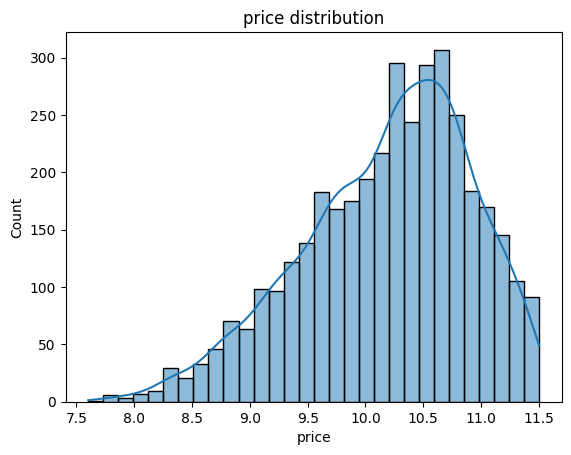

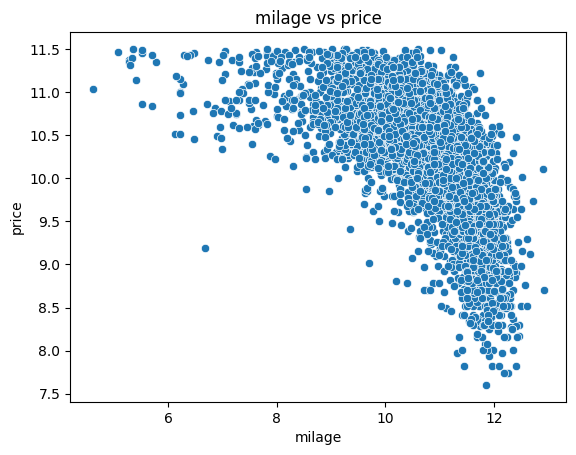

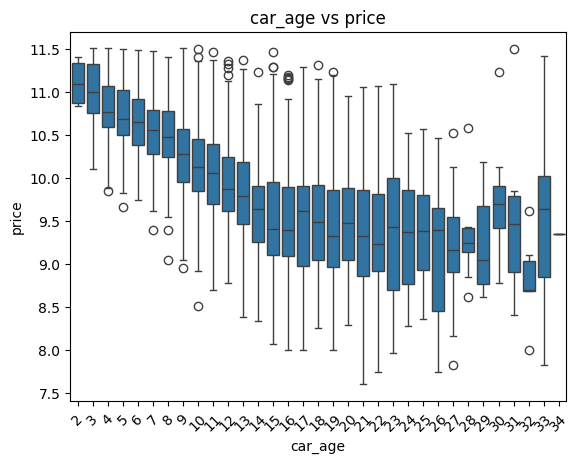

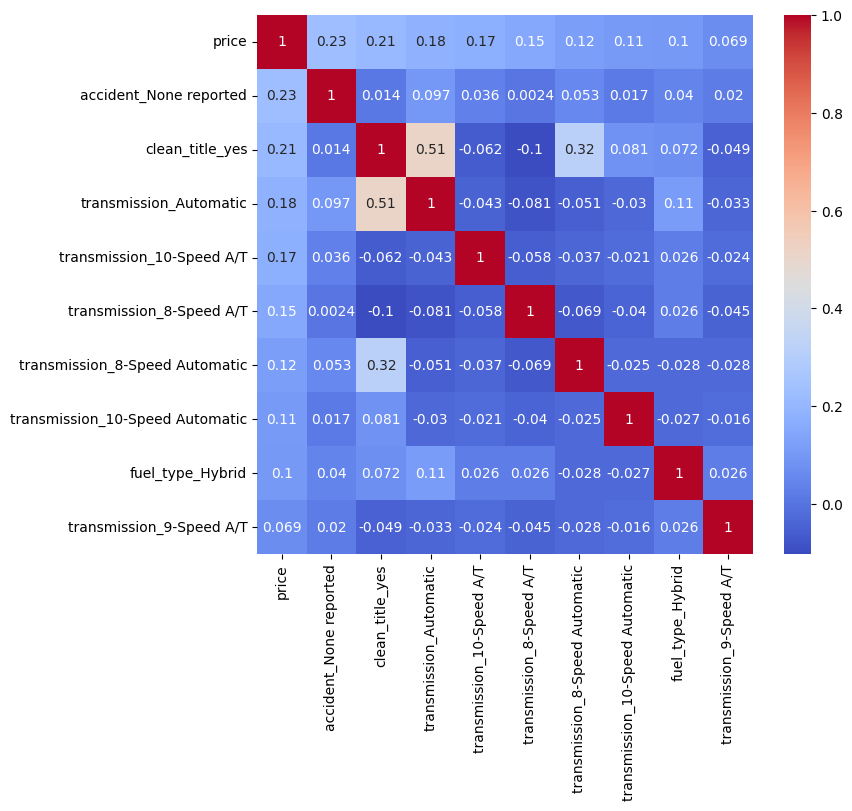

In [8]:
#price distribution
sns.histplot(df['price'], bins=30, kde=True)
plt.title('price distribution')
plt.show()
# milage vs price
sns.scatterplot(x=df['milage'],y=df['price'])
plt.title('milage vs price')
plt.show()
# year vs price
sns.boxplot(x=df['car_age'], y=df['price'])
plt.title('car_age vs price')
plt.xticks(rotation=45)
plt.show()
#correlation
corr = df.corr()['price'].sort_values(ascending=False)

# select top 10 correlated features
top_features = corr.head(10).index

plt.figure(figsize=(8,7))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.show()

***# 7. FEATURE ENGINEERING***

In [7]:
# 1. Create car_age and drop model_year
if 'model_year' in df.columns:
    df['car_age'] = 2026 - df['model_year']
    df = df.drop('model_year', axis=1) # Using direct assignment to modify df
    print("Created 'car_age' and dropped 'model_year'.")
else:
    print("'model_year' not found, assuming 'car_age' is already created or not needed.")

# 2. Target Encoding (For High Cardinality Columns)
high_card_cols = ['brand', 'model']
for col in high_card_cols:
    if col in df.columns: # This check handles the case where they are already dropped
        df[col + '_encoded'] = df.groupby(col)['price'].transform('mean')
        print(f"Target Encoding applied on: {col}")

# 3. One-Hot Encoding for Low Cardinality Columns
potential_one_hot_cols = ['fuel_type', 'transmission', 'accident', 'clean_title']
cols_to_one_hot_encode = [col for col in potential_one_hot_cols if col in df.columns and df[col].dtype == 'object']

if cols_to_one_hot_encode:
    df = pd.get_dummies(df, columns=cols_to_one_hot_encode, drop_first=True)
    print(f"One-Hot Encoding applied on: {cols_to_one_hot_encode}")
else:
    print("No specified categorical columns found for One-Hot Encoding. They might have been processed already.")

# Drop Original Text Columns (that might still be present after encoding or were meant to be dropped earlier)
drop_cols = ['brand', 'model', 'engine', 'ext_col', 'int_col', 'transmission', 'fuel_type', 'accident', 'clean_title']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

print("✅ Feature Engineering Completed")
print("Final Shape:", df.shape)
print("Columns:", df.columns.tolist())

Created 'car_age' and dropped 'model_year'.
One-Hot Encoding applied on: ['fuel_type', 'transmission', 'accident', 'clean_title']
✅ Feature Engineering Completed
Final Shape: (3765, 64)
Columns: ['milage', 'price', 'car_age', 'fuel_type_E85 Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid', 'fuel_type_Plug-In Hybrid', 'fuel_type_not supported', 'fuel_type_–', 'transmission_1-Speed Automatic', 'transmission_10-Speed A/T', 'transmission_10-Speed Automatic', 'transmission_2', 'transmission_2-Speed A/T', 'transmission_4-Speed A/T', 'transmission_4-Speed Automatic', 'transmission_5-Speed A/T', 'transmission_5-Speed Automatic', 'transmission_5-Speed M/T', 'transmission_6 Speed At/Mt', 'transmission_6 Speed Mt', 'transmission_6-Speed', 'transmission_6-Speed A/T', 'transmission_6-Speed Automatic', 'transmission_6-Speed Automatic with Auto-Shift', 'transmission_6-Speed Electronically Controlled Automatic with O', 'transmission_6-Speed M/T', 'transmission_6-Speed Manual', 'transmission_7-Spee

***8. REMOVE HIGHLY CORRELATED FEATURES***

In [9]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))# select upper tringle
# find highly correlated features
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
df = df.drop(to_drop, axis=1)
#  CREATE CLASSIFICATION TARGET
df['Car_Quality'] = pd.qcut(df['price'], q=3, labels=['Bad', 'Average', 'Good'])

print("Car Quality Class Distribution:")
print(df['Car_Quality'].value_counts())

Car Quality Class Distribution:
Car_Quality
Bad        1255
Average    1255
Good       1255
Name: count, dtype: int64


***9. SPLIT DATA***

In [10]:
# separate features and target
X = df.drop(['price', 'Car_Quality'], axis=1)
y_reg = np.log1p(df['price'])           # Regression Target
y_clf = df['Car_Quality']               #classification target
# train_test_split the data
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Splitting and Scaling Completed")

✅ Data Splitting and Scaling Completed


 ***10. Model Training & Evaluation***

In [11]:
# REGRESSION MODELS (Price Prediction)
reg_models = {
    "Multiple Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42)
}

reg_results = []

for name, model in reg_models.items():
    model.fit(X_train_scaled, y_train_reg)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)

    reg_results.append({
        'Model': name,
        'RMSE': round(rmse, 4),
        'R² Score': round(r2, 4)
    })

    print(f"{name:30} -> RMSE: {rmse:.4f} | R²: {r2:.4f}")

reg_df = pd.DataFrame(reg_results)
display(reg_df)

Multiple Linear Regression     -> RMSE: 0.0425 | R²: 0.5751
KNN Regressor                  -> RMSE: 0.0422 | R²: 0.5795
Random Forest Regressor        -> RMSE: 0.0409 | R²: 0.6057


,Model,RMSE,R² Score
0,Multiple Linear Regression,0.0425,0.5751
1,KNN Regressor,0.0422,0.5795
2,Random Forest Regressor,0.0409,0.6057


***11.CLASSIFICATION MODELS (Car Quality)***

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=7)
}

clf_results = []

for name, model in clf_models.items():
    model.fit(X_train_scaled, y_train_clf)        # Note: Using same scaled data
    y_pred_clf = model.predict(X_test_scaled)

    acc = accuracy_score(y_test_clf, y_pred_clf)

    clf_results.append({
        'Model': name,
        'Accuracy': round(acc, 4)
    })

    print(f"{name:30} -> Accuracy: {acc:.4f}")
    print(classification_report(y_test_clf, y_pred_clf))
    print("-" * 50)

clf_df = pd.DataFrame(clf_results)
display(clf_df)

Logistic Regression            -> Accuracy: 0.6773
              precision    recall  f1-score   support

     Average       0.52      0.59      0.55       245
         Bad       0.77      0.80      0.79       254
        Good       0.76      0.64      0.70       254

    accuracy                           0.68       753
   macro avg       0.68      0.68      0.68       753
weighted avg       0.69      0.68      0.68       753

--------------------------------------------------
KNN Classifier                 -> Accuracy: 0.6348
              precision    recall  f1-score   support

     Average       0.47      0.54      0.50       245
         Bad       0.74      0.73      0.74       254
        Good       0.71      0.63      0.67       254

    accuracy                           0.63       753
   macro avg       0.64      0.63      0.64       753
weighted avg       0.65      0.63      0.64       753

--------------------------------------------------


,Model,Accuracy
0,Logistic Regression,0.6773
1,KNN Classifier,0.6348


***12. Save Models for Deployment***

In [13]:
import joblib

# Save Best Regression Model (Random Forest)
joblib.dump(reg_models["Random Forest Regressor"], 'best_car_price_model.pkl')

# Save Best Classification Model
joblib.dump(clf_models["KNN Classifier"], 'car_quality_model.pkl')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("✅ All Models Saved Successfully!")
print("You can now use these files in your Streamlit Web Application.")

✅ All Models Saved Successfully!
You can now use these files in your Streamlit Web Application.


***Streamlit Web Application***

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Page Configuration
st.set_page_config(page_title="Used Car Predictor", layout="centered")
st.title("🚗 Used Car Price & Quality Predictor")
st.markdown("**MSc Data Science Project**")

# Load Models
@st.cache_resource
def load_models():
    price_model = joblib.load('best_car_price_model.pkl')
    quality_model = joblib.load('car_quality_model.pkl')
    scaler = joblib.load('scaler.pkl')
    features = joblib.load('feature_columns.pkl')
    return price_model, quality_model, scaler, features

price_model, quality_model, scaler, features = load_models()

# ====================== User Inputs ======================
st.sidebar.header("Enter Car Details")

car_age = st.sidebar.number_input("Car Age (in years)", min_value=0, max_value=30, value=5)
milage = st.sidebar.number_input("Mileage (miles)", min_value=0, max_value=300000, value=45000)

brand = st.sidebar.selectbox("Brand", ["Toyota", "Honda", "Ford", "BMW", "Mercedes-Benz",
                                       "Audi", "Lexus", "Tesla", "Hyundai", "Kia", "Other"])

fuel_type = st.sidebar.selectbox("Fuel Type", ["Gasoline", "Hybrid", "Electric", "Diesel"])
accident = st.sidebar.selectbox("Accident History", ["None reported", "At least 1 accident or damage reported"])
clean_title = st.sidebar.selectbox("Clean Title", ["Yes", "No"])

# ====================== Prepare Input Data ======================
input_data = pd.DataFrame(0, index=[0], columns=features)

# Fill numerical features
input_data['car_age'] = car_age
input_data['milage'] = milage

# Approximate encoding for brand (you can improve this later)
if 'brand_encoded' in features:
    input_data['brand_encoded'] = 28000  # Average price approximation

# Fill categorical features
if f'fuel_type_{fuel_type}' in features:
    input_data[f'fuel_type_{fuel_type}'] = 1

if f'accident_{accident}' in features:
    input_data[f'accident_{accident}'] = 1

if f'clean_title_{clean_title}' in features:
    input_data[f'clean_title_{clean_title}'] = 1

# ====================== Make Predictions ======================
input_scaled = scaler.transform(input_data)

# Price Prediction
price_log = price_model.predict(input_scaled)
predicted_price = np.expm1(price_log[0])

# Quality Prediction
quality_pred = quality_model.predict(input_scaled)[0]

# ====================== Display Results ======================
col1, col2 = st.columns(2)

with col1:
    st.success(f"**Predicted Price**\n${predicted_price:,.0f}")

with col2:
    if quality_pred == "Good":
        st.success(f"**Car Quality**\n{quality_pred} 🟢")
    elif quality_pred == "Average":
        st.warning(f"**Car Quality**\n{quality_pred} 🟡")
    else:
        st.error(f"**Car Quality**\n{quality_pred} 🔴")

st.info("Note: This is a demonstration model trained on used car data.")

Overwriting app.py
